<a href="https://colab.research.google.com/github/swastik2207/EEG_Depression_Detection_Project/blob/main/Updated_MODMA_Preprocessed_CNN%2BRNN%2BGA%2BSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install Py-FS
!pip install ReliefF
!pip install tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ReliefF: filename=ReliefF-0.1.2-py3-none-any.whl size=6303 sha256=5ec2c0200bfa278031e5e7b8e6c83031f58ff94609eb65b1cc7e14bfaae3e242
  Stored in directory: /root/.cache/pip/wheels/18/bb/86/39ea046cb24e9e508e37ddc643a982097c91e5837c93e824f2
Successfully built ReliefF


In [ ]:
!unzip "/content/drive/MyDrive/EEG_128channels_resting_lanzhou_2015 (1).zip"

Archive:  /content/drive/MyDrive/EEG_128channels_resting_lanzhou_2015 (1).zip
   creating: EEG_128channels_resting_lanzhou_2015/
  inflating: EEG_128channels_resting_lanzhou_2015/02010013rest 20150703 1333..mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02010012rest 20150626 1026..mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02020022rest 20150707 1452..mat  
  inflating: EEG_128channels_resting_lanzhou_2015/Multivariate Pattern Analysis of EEG-Based Functional Connectivity A Study on the Identification of Depression.pdf  
  inflating: EEG_128channels_resting_lanzhou_2015/02010019rest 20150716 1440..mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02030020_rest 20151230 1416.mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02010005rest 20150507 0907..mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02010022restnew 20150724 14.mat  
  inflating: EEG_128channels_resting_lanzhou_2015/02010033rest 20160331 1239..mat  
  inflating: EEG_128channels_res

In [ ]:

import pandas as pd
df = pd.read_excel("/content/EEG_128channels_resting_lanzhou_2015/subjects_information_EEG_128channels_resting_lanzhou_2015.xlsx")
df

,subject id,type,age,gender,education（years）,PHQ-9,CTQ-SF,LES,SSRS,GAD-7,PSQI,Unnamed: 11,Unnamed: 12
0,2010002,MDD,18,F,12,23,77,-143,31,18,12,NaN,abbreviation
1,2010004,MDD,25,F,19,12,53,-44,38,13,11,NaN,MDD = Major Depressive Disorder
2,2010005,MDD,20,M,16,19,49,-3,28,11,5,NaN,HC = Healthy Control
3,2010006,MDD,42,M,16,16,59,-30,40,12,9,NaN,PHQ-9 = Patient Health Questionnaire
4,2010008,MDD,42,M,12,17,66,-71,44,18,13,NaN,CTQ-SF = Childhood Trauma Questionnaire
5,2010010,MDD,34,M,6,19,50,0,32,20,21,NaN,LES = Life Event Scale
6,2010011,MDD,45,M,9,24,47,0,26,13,15,NaN,SSRS = Social Support Research Scale
7,2010012,MDD,21,F,16,22,38,-2,41,14,16,NaN,GAD-7 = Generalized Anxiety Disorder
8,2010013,MDD,21,F,16,11,50,-165,29,7,11,NaN,PSQI = Pittsburgh Sleep Quality Index
9,2010015,MDD,26,M,16,14,51,-20,35,10,4,NaN,remarks


In [ ]:
import scipy.io
import os
from sklearn.preprocessing import LabelEncoder

path = "/content/EEG_128channels_resting_lanzhou_2015"
dir_list = os.listdir(path)


X=[]
y=[]


for file in dir_list:
    if file.endswith(".mat"):
        subject_id = file[1:8]

        # Find matching row in DataFrame
        match_row = df[df["subject id"].astype(str) == subject_id]

        if not match_row.empty:
            label = match_row["type"].values[0]

            mat = scipy.io.loadmat(os.path.join(path, file))

            # Filter out default MATLAB keys
            valid_keys = [key for key in mat.keys() if not key.startswith("__")]

            if valid_keys:
                X.append(mat[valid_keys[0]])
                y.append(label)
            else:
                print(f"No valid keys found in file: {file}")
        else:
            print(f"No match found for subject_id: {subject_id}")

le = LabelEncoder()
y= le.fit_transform(y)
print(y)

[1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0
 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 1]


In [ ]:
import scipy.io as sio
import os

# Set path to one sample .mat file in your MODMA EEG dataset (adjust as needed)
data_dir = '/content/EEG_128channels_resting_lanzhou_2015'
sample_file = '02030004_rest 20151026 1930.mat'  # Change this to any file you want to inspect

file_path = os.path.join(data_dir, sample_file)

# Load the .mat file
mat_data = sio.loadmat(file_path)

# Print the keys in the .mat file to check what data is present
print("Keys in .mat file:")
print(mat_data.keys())

# Explore main keys ignoring those starting with '__' (metadata)
#for key in mat_data:
   # if not key.startswith('__'):
       # print(f"Key: {key} | Type: {type(mat_data[key])} | Shape (if applicable): {getattr(mat_data[key], 'shape', 'N/A')}")


Keys in .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'a02030004_rest_20151026_1930mat', 'samplingRate', 'Impedances_0', 'DIN_1'])


In [ ]:
#eeg_key = 'a02030004_rest_20151026_1930mat'
eeg_data = X[0]  # shape (channels, samples)

# Extract sampling rate
sampling_rate = mat_data['samplingRate'][0][0]

print(f"EEG data shape (channels, samples): {eeg_data.shape}")
print(f"Sampling rate: {sampling_rate} Hz")

# Transpose EEG data to (samples, channels)
eeg_data = eeg_data.T
print(f"EEG data shape after transpose (samples, channels): {eeg_data.shape}")


EEG data shape (channels, samples): (129, 75189)
Sampling rate: 250.0 Hz
EEG data shape after transpose (samples, channels): (75189, 129)


In [ ]:
  def butter_bandpass(lowcut, highcut, fs, order=5):
      nyq = 0.5 * fs
      low = lowcut / nyq
      high = highcut / nyq
      b, a = butter(order, [low, high], btype='band')
      return b, a

  def bandpass_filter(data, lowcut, highcut, fs, order=5):
      b, a = butter_bandpass(lowcut, highcut, fs, order=order)
      y = lfilter(b, a, data, axis=0)
      return y

  # Apply bandpass filter
  lowcut = 1.0
  highcut = 45.0

  def segment_eeg(data, window_size, step_size):
      segments = []
      for start in range(0, data.shape[0] - window_size + 1, step_size):
          segment = data[start:start + window_size, :]
          segments.append(segment)
      return np.array(segments)

  def normalize_segments(segments):
      # Subtract mean and divide by std dev across axes (time and channels)
      mean = segments.mean(axis=(1, 2), keepdims=True)
      std = segments.std(axis=(1, 2), keepdims=True)
      segments_norm = (segments - mean) / (std + 1e-8)
      return segments_norm


In [ ]:
import numpy as np
from scipy.signal import butter, lfilter

# --- (Your helper functions like butter_bandpass, bandpass_filter,
# ---  segment_eeg go here) ---

# Initialize as empty Python lists
all_labels = []
all_segments = []

# Assume X and y are loaded, and sampling_rate is defined
lowcut = 1.0
highcut = 45.0
sampling_rate = 250 # Example: You must define this

for idx, eeg_data in enumerate(X):
    # shape (channels, samples)

    # --- THIS IS THE CHANGE ---
    # We only want indices 0-6 and 40-46.

    # 1. Efficiency Check: If we are past the highest index we care about (46), stop.
    if idx > 44:
        print("Reached past index 46. Stopping loop.")
        break

    # 2. Filtering Logic: If idx is NOT in 0-6 AND NOT in 40-46, skip it.
    if not ((0 <= idx <= 10)):
        # print(f"Skipping file {idx}...") # Optional: uncomment to see skips
        continue
    # --- END OF CHANGE ---

    print(f"Processing file {idx}...")
    print(f"EEG data shape (channels, samples): {eeg_data.shape}")

    # Transpose EEG data to (samples, channels)
    eeg_data = eeg_data.T
    print(f"EEG data shape after transpose (samples, channels): {eeg_data.shape}")

    # Apply filter
    eeg_filtered = bandpass_filter(eeg_data, lowcut, highcut, sampling_rate)

    # --- Segment EEG into windows ---
    window_seconds = 20
    window_size = int(window_seconds * sampling_rate)  # 2500 samples/window
    step_size = window_size  # Non-overlapping

    # Correctly calculate the number of segments
    if eeg_filtered.shape[0] < window_size:
        print(f"Skipping file {idx}: data is shorter than window size.")
        continue # Skip this file

    segment_numbers = int((eeg_filtered.shape[0] - window_size) / step_size) + 1

    new_eeg_segments = segment_eeg(eeg_filtered, window_size, step_size)
    print(f"Generated {new_eeg_segments.shape[0]} segments.")

    # Create the labels for these new segments
    new_labels = np.full(segment_numbers, y[idx]) # Use the calculated segment_numbers
    print(y[idx])
    # Append the 3D array as a single item to the list
    all_segments.append(new_eeg_segments)

    # Use .extend() to add all items from new_labels to the list, keeping it flat
    all_labels.extend(new_labels)

# --- AFTER THE LOOP FINISHES ---
# Now, stack all the collected arrays at once.

print("\nLoop finished. Concatenating all segments...")

# np.concatenate will stack all the 3D arrays in the list along axis 0
# Add a check in case no files were processed
if all_segments:
    eeg_segments = np.concatenate(all_segments, axis=0)
    labels = np.array(all_labels)

    print(f"Final segments shape: {eeg_segments.shape}")
    print(f"Final labels shape: {labels.shape}")
else:
    print("No segments were processed.")
    eeg_segments = np.array([])
    labels = np.array([])

Processing file 0...
EEG data shape (channels, samples): (129, 75189)
EEG data shape after transpose (samples, channels): (75189, 129)


/tmp/ipykernel_2901/2554580573.py:10: DeprecationWarning: dtype=>f8 is not supported by lfilter and will raise an error in SciPy 1.17.0. Supported dtypes are: boolean, integer, `np.float16`,`np.float32`, `np.float64`, `np.complex64`, `np.complex128`.
  y = lfilter(b, a, data, axis=0)


Generated 15 segments.
1
Processing file 1...
EEG data shape (channels, samples): (129, 75151)
EEG data shape after transpose (samples, channels): (75151, 129)
Generated 15 segments.
0
Processing file 2...
EEG data shape (channels, samples): (129, 75525)
EEG data shape after transpose (samples, channels): (75525, 129)
Generated 15 segments.
0
Processing file 3...
EEG data shape (channels, samples): (129, 75339)
EEG data shape after transpose (samples, channels): (75339, 129)
Generated 15 segments.
1
Processing file 4...
EEG data shape (channels, samples): (129, 75276)
EEG data shape after transpose (samples, channels): (75276, 129)
Generated 15 segments.
1
Processing file 5...
EEG data shape (channels, samples): (129, 75139)
EEG data shape after transpose (samples, channels): (75139, 129)
Generated 15 segments.
0
Processing file 6...
EEG data shape (channels, samples): (129, 75126)
EEG data shape after transpose (samples, channels): (75126, 129)
Generated 15 segments.
0
Processing file

In [ ]:
print(labels)
def normalize_segments(segments):
    # Subtract mean and divide by std dev across axes (time and channels)
    mean = segments.mean(axis=(1, 2), keepdims=True)
    std = segments.std(axis=(1, 2), keepdims=True)
    segments_norm = (segments - mean) / (std + 1e-8)
    return segments_norm

eeg_segments_normalized = normalize_segments(eeg_segments)
print(f"Normalized EEG segments shape: {eeg_segments_normalized.shape}")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Normalized EEG segments shape: (165, 5000, 129)


In [ ]:
import numpy as np
import os

os.makedirs('/content/working', exist_ok=True)



# Save the segments and labels
np.save('/content/working/eeg_segments.npy', eeg_segments_normalized)
np.save('/content/working/labels.npy', labels)

print("Segments and labels saved successfully.")

Segments and labels saved successfully.


In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

# --- New Imports for Proposed Framework ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, PReLU, MaxPooling2D, Flatten, Reshape,
    Bidirectional, LSTM, GRU, Dense, Dropout,
    GlobalAveragePooling2D, Multiply, Permute, Input
)

# --- Load Data ---
try:
    eeg_segments = np.load('/content/working/eeg_segments.npy')
    labels = np.load('/content/working/labels.npy')
    # Removed groups.npy loading

    print(f"Loaded EEG segments: {eeg_segments.shape}")
    print(f"Loaded labels: {labels.shape}")
except FileNotFoundError:
    print("Error: Files not found. Run the 'Preprocessing' script first.")
    exit()

X_train, X_val, y_train, y_val = train_test_split(eeg_segments, labels, test_size=0.2, stratify=labels, random_state=42)



Loaded EEG segments: (165, 5000, 129)
Loaded labels: (165,)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, PReLU, MaxPooling2D, Flatten, Reshape,
    Bidirectional, LSTM, GRU, Dense, Dropout,
    GlobalAveragePooling2D, Multiply, Input, BatchNormalization
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import os


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, PReLU, MaxPooling2D, Reshape,
    Bidirectional, LSTM, GRU, Dense, Dropout,
    GlobalAveragePooling2D, Multiply, Input, BatchNormalization,
    Concatenate, Add, Lambda
)
from tensorflow.keras.regularizers import l2


# ================================
# ✅ Channel Attention (Fixed)
# ================================
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = Dense(
            self.filters // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True,
            bias_initializer='zeros'
        )
        self.shared_layer_two = Dense(
            self.filters,
            kernel_initializer='he_normal',
            use_bias=True,
            bias_initializer='zeros'
        )
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        avg_pool = GlobalAveragePooling2D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        scale = tf.keras.activations.sigmoid(avg_pool)
        scale = Reshape((1, 1, self.filters))(scale)

        return Multiply()([inputs, scale])


# ================================
# ✅ Feature Extractor (FIXED)
# ================================
def build_feature_extractor(input_shape):
    reg = l2(0.001)
    inputs = Input(shape=input_shape)

    # reshape → (time, 1, channels)
    x = Reshape((input_shape[0], 1, input_shape[1]))(inputs)

    # ================================
    # 🧠 CNN BLOCK
    # ================================
    for _ in range(4):
        x = Conv2D(128, (3, 1), padding='same')(x)
        x = BatchNormalization()(x)
        x = PReLU()(x)

    # ⚡ reduce sequence length more aggressively (important)
    x = MaxPooling2D((5, 1))(x)
    x = Dropout(0.3)(x)

    # ✅ Channel Attention
    x = ChannelAttention(filters=128)(x)

    cnn_out = x

    # ================================
    # 📌 SPATIAL FEATURES
    # ================================
    spatial = GlobalAveragePooling2D()(cnn_out)
    spatial = Dense(256)(spatial)
    spatial = BatchNormalization()(spatial)
    spatial = PReLU()(spatial)

    # ================================
    # 📌 TEMPORAL FEATURES (FIXED)
    # ================================
    # ✅ NO tf.shape → only Keras-safe reshape
    rnn = Reshape((cnn_out.shape[1], cnn_out.shape[-1]))(cnn_out)

    rnn = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3))(rnn)
    rnn = Bidirectional(GRU(128, return_sequences=False, dropout=0.3))(rnn)

    temporal = Dense(256)(rnn)
    temporal = BatchNormalization()(temporal)
    temporal = PReLU()(temporal)

    # ================================
    # 🔀 MULTI-HEAD GATED FUSION
    # ================================
    num_heads = 4
    fusion_input = Concatenate()([spatial, temporal])

    head_outputs = []

    for _ in range(num_heads):
        gate = Dense(256, activation='sigmoid')(fusion_input)
        inv_gate = Lambda(lambda g: 1.0 - g)(gate)

        spatial_w = Multiply()([spatial, gate])
        temporal_w = Multiply()([temporal, inv_gate])

        fused = Add()([spatial_w, temporal_w])
        head_outputs.append(fused)

    fusion = Concatenate()(head_outputs)

    fusion = Dense(256)(fusion)
    fusion = BatchNormalization()(fusion)
    fusion = PReLU()(fusion)

    # ================================
    # 🎯 FINAL FEATURES
    # ================================
    x = Dense(128, kernel_regularizer=reg)(fusion)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    x = Dropout(0.4)(x)

    features = Dense(256, kernel_regularizer=reg, name='svm_features')(x)
    features = BatchNormalization()(features)
    features = PReLU()(features)

    outputs = Dense(3, activation='softmax')(features)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # change here
    metrics=['accuracy']
)

    return model


# ================================
# ✅ BUILD MODEL
# ================================
input_shape = (5000, 129)
model = build_feature_extractor(input_shape)

model.summary()

print("\n--- Training Optimized Feature Extractor ---")
# Lowering batch_size is critical for long sequences
model_save_path = 'best_eeg_feature_extractor.keras'

callbacks = [
    ModelCheckpoint(
        model_save_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

# 3. Training
# batch_size=8 is used to prevent Out-of-Memory (OOM) on long sequences
print("\n--- Phase 1: Training Deep Feature Extractor ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=8,
    callbacks=callbacks,

)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5000, 129) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 5000, 1,   │          0 │ input_layer_2[0]… │
│                     │ 129)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 5000, 1,   │     49,664 │ reshape_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 1,   │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_14 (PReLU)  │ (None, 5000, 1,   │    640,000 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 5000, 1,   │     49,280 │ p_re_lu_14[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 1,   │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_15 (PReLU)  │ (None, 5000, 1,   │    640,000 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 5000, 1,   │     49,280 │ p_re_lu_15[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 1,   │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_16 (PReLU)  │ (None, 5000, 1,   │    640,000 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 5000, 1,   │     49,280 │ p_re_lu_16[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 1,   │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_17 (PReLU)  │ (None, 5000, 1,   │    640,000 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 1000, 1,   │          0 │ p_re_lu_17[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1000, 1,   │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention_2 │ (None, 1000, 1,   │      4,240 │ dropout_3[0][0] 

 Total params: 5,004,307 (19.09 MB)

 Trainable params: 5,000,979 (19.08 MB)

 Non-trainable params: 3,328 (13.00 KB)


--- Training Optimized Feature Extractor ---

--- Phase 1: Training Deep Feature Extractor ---
Epoch 1/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.2896 - loss: 1.7250
Epoch 1: val_accuracy improved from None to 0.30303, saving model to best_eeg_feature_extractor.keras

Epoch 1: finished saving model to best_eeg_feature_extractor.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 381ms/step - accuracy: 0.3485 - loss: 1.6378 - val_accuracy: 0.3030 - val_loss: 1.4354
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4384 - loss: 1.3413
Epoch 2: val_accuracy improved from 0.30303 to 0.78788, saving model to best_eeg_feature_extractor.keras

Epoch 2: finished saving model to best_eeg_feature_extractor.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.5076 - loss: 1.3044 - val_accuracy: 0.7879 - val_loss: 1.4095
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5707 - loss: 1.1718
Epoch 3: val_accuracy did not improve from 0.78788
17/17 ━━━━━━━━━━━


[Phase 2] Extracting features from best model...
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 313ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step

[Phase 2] Optimizing 512 features via Genetic Algorithm...
Weight for the classification accuracy [0-1]: 0.2
Enter the percentage of data wanted for valdiation [0, 100]: 20

                          Iteration - 1

Crossover-Mutation phase starting....

Crossover no. 1
child 1 replaced with chromosome having id 13
child 2 replaced with chromosome having id 14

Crossover no. 2
Crossover failed....
Restarting crossover....


Crossover no. 2
child 1 replaced with chromosome having id 10
child 2 replaced with chromosome having id 13

Crossover no. 3
child 1 replaced with chromosome having id 9
child 2 replaced with chromosome having id 10

Crossover no. 4
child 1 replaced with chromosome having id 12
child 2 replaced with chromosome having id 15

Crossover no. 5
child 1 replaced with chromosome having id 14
child 2 replaced with chromosome having id 16

Number 

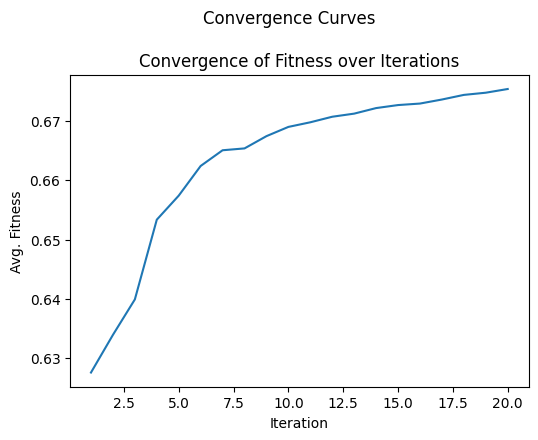

GA pruned features from 512 down to: 76

[Phase 3] Training Final SVM...

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        21
     Class 1       1.00      1.00      1.00        12

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



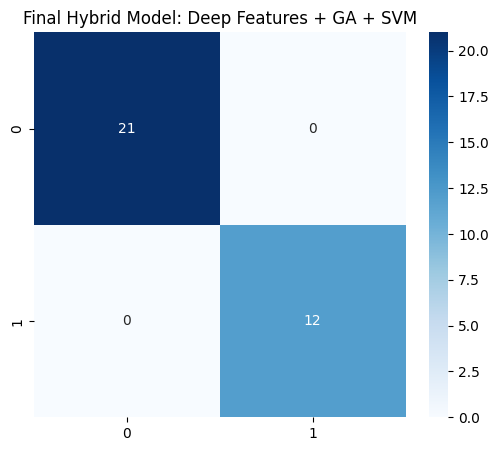

In [ ]:
# --- BLOCK 2: Genetic Algorithm (Py_FS) and SVM Classification ---
from Py_FS.wrapper.nature_inspired import GA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Best Model
# We include ChannelAttention in custom_objects so Keras knows how to load it
best_model = tf.keras.models.load_model(
    'best_eeg_feature_extractor.keras',
    custom_objects={'ChannelAttention': ChannelAttention},
    safe_mode=False   # ✅ ADD THIS
)

# 2. Isolate the 512-dim Feature Layer
extractor = Model(inputs=best_model.input, outputs=best_model.get_layer('svm_features').output)

# 3. Extract and Scale Features
print("\n[Phase 2] Extracting features from best model...")
train_feat = extractor.predict(X_train, batch_size=8)
val_feat = extractor.predict(X_val, batch_size=8)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_feat)
X_val_scaled = scaler.transform(val_feat)

# 4. Genetic Algorithm Selection
print("\n[Phase 2] Optimizing 512 features via Genetic Algorithm...")
# num_agents: solutions, max_iter: generations
solution = GA(num_agents=20, max_iter=20, train_data=X_train_scaled, train_label=y_train)
selected_mask = solution.best_agent

# Apply the GA Mask
X_train_ga = X_train_scaled[:, selected_mask == 1]
X_val_ga = X_val_scaled[:, selected_mask == 1]
print(f"GA pruned features from 512 down to: {X_train_ga.shape[1]}")

# 5. Final SVM Classification

print("\n[Phase 3] Training Final SVM...")
svm_final = SVC(kernel='rbf', C=1.5, class_weight='balanced', probability=True)
svm_final.fit(X_train_ga, y_train)

# 6. Evaluation
y_pred = svm_final.predict(X_val_ga)
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_val, y_pred, target_names=['Class 0', 'Class 1']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Final Hybrid Model: Deep Features + GA + SVM')
plt.show()